In [1]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tqdm as tq

In [2]:
def read_cococonet(species_1):
    """[Takes a species name in any format, and returns a CoCoConet for that species]

    Args:
        species_1 ([str]): [Species in CoCoCoNet]

    Returns:
        [Panda Dataframe]: [GenexGene Matrix]
    """
    import h5py
    import pandas as pd
    import Name_resolver as nr

    assert (type(species_1) == str ), 'Species Must Be A String'

    common_name_of_species = nr.species_name_resolver(species_1= species_1, desired_type='common')


    cococonet_map = pd.read_csv('/vault/transfer/passala/Generated_Tables/Reference_tables/All_CoCoCoNet_Paths.csv')
    file_location = cococonet_map['Path'].loc[cococonet_map['Common Name'] == common_name_of_species].item()

    net = h5py.File(file_location,'r')
    agg_dataset = net['agg'] 
    row_dataset = net['row']
    col_dataset = net['col']
    row_gene_list = []
    for gene in row_dataset:
        row_gene_list.append(gene.decode('UTF-8'))
    col_gene_list = []
    for gene in col_dataset: 
        col_gene_list.append(gene.decode('UTF-8'))
    net_df = pd.DataFrame(data = agg_dataset[:,:], index = row_gene_list, columns = col_gene_list)
    net.close()
    return net_df 

In [7]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [4]:
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups

,Orthogroup,Gene,Species,Ortholevel,Orthodb Gene,Symbol
0,100007at3193,4558_0:003a4f,4558,3193,4558_0:003a4f,LOC110434333
1,100007at3193,4577_0:004254,4577,3193,4577_0:004254,LOC100276500
2,100007at3193,4577_0:004e43,4577,3193,4577_0:004e43,LOC100275058
3,100067at3193,4558_0:00439a,4558,3193,4558_0:00439a,LOC8071983
4,100085at3193,4558_0:002fd8,4558,3193,4558_0:002fd8,LOC8086335
...,...,...,...,...,...,...
502887,9969at3193,15368_0:000e9a,15368,3193,15368_0:000e9a,LOC100834561
502888,99917at3193,39947_0:006297,39947,3193,39947_0:006297,LOC107276177
502889,99917at3193,39947_0:00634f,39947,3193,39947_0:00634f,LOC9269479
502890,99917at3193,39947_0:006629,39947,3193,39947_0:006629,LOC9269626


In [5]:
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [8]:
maize_og = get_ncbi_clean_og2gene_for_species(
    4577 , og_groups, ncbi_mapping=ncbi_mapping
)

inner_loop:   0%|          | 0/14596 [00:00<?, ?it/s]

In [9]:
sorg_og = get_ncbi_clean_og2gene_for_species(
    3702, og_groups, ncbi_mapping=ncbi_mapping
)

inner_loop:   0%|          | 0/15558 [00:00<?, ?it/s]

In [10]:
maize_og

,4577 OrthoGene,Orthogroup,Symbol
0,4577_0:004254,100007at3193,Zm00001d017285
1,4577_0:004e43,100007at3193,LOC100275058
2,4577_0:002a40,10009at3193,LOC103650270
3,4577_0:0055c7,100242at3193,Zm00001d036270
4,4577_0:00571d,100242at3193,Zm00001d036267
...,...,...,...
29980,4577_0:000740,99460at3193,LOC100275919
29981,4577_0:000d05,9959at3193,Zm00001d010566
29982,4577_0:002b38,9959at3193,LOC100192600
29983,4577_0:004be5,9959at3193,LOC103625771


In [11]:
sorg_og

,3702 OrthoGene,Orthogroup,Symbol
0,3702_0:006584,10009at3193,AT5G42200
1,3702_0:001f5f,10092at3193,AT2G26300
2,3702_0:000e32,10147at3193,AT1G73910
3,3702_0:0018a2,10147at3193,AT1G18450
4,3702_0:000573,10228at3193,AT1G49040
...,...,...,...
25982,3702_0:004152,9877at3193,AT3G58740
25983,3702_0:00114d,9919at3193,AT1G15440
25984,3702_0:002571,9942at3193,AT2G44100
25985,3702_0:003134,9942at3193,AT3G59920


In [12]:
list_of_non_single_gene_groups_maize = pd.Series(maize_og['Orthogroup'].value_counts().loc[maize_og['Orthogroup'].value_counts() >1])

In [13]:
list_of_non_single_gene_groups_sorg = pd.Series(sorg_og['Orthogroup'].value_counts().loc[sorg_og['Orthogroup'].value_counts() >1])

In [14]:
list_of_non_single_gene_groups_sorg

Orthogroup
71601at3193     30
889985at3193    29
784291at3193    26
305752at3193    26
31749at3193     25
                ..
886139at3193     2
886191at3193     2
279836at3193     2
881138at3193     2
881005at3193     2
Name: count, Length: 5276, dtype: int64

In [15]:
list_of_non_single_gene_groups_maize

Orthogroup
334151at3193    61
83993at3193     52
942820at3193    33
227973at3193    31
78311at3193     31
                ..
104520at3193     2
10493at3193      2
105017at3193     2
103637at3193     2
103928at3193     2
Name: count, Length: 6861, dtype: int64

In [16]:
maize_og = maize_og.loc[maize_og['Orthogroup'].isin(list_of_non_single_gene_groups_maize.index)]

In [17]:
sorg_og = sorg_og.loc[sorg_og['Orthogroup'].isin(list_of_non_single_gene_groups_sorg.index)]

In [18]:
sorg_og

,3702 OrthoGene,Orthogroup,Symbol
2,3702_0:000e32,10147at3193,AT1G73910
3,3702_0:0018a2,10147at3193,AT1G18450
6,3702_0:0003d0,10488at3193,AT1G08260
7,3702_0:00201b,10488at3193,AT2G27120
13,3702_0:0035a8,10772at3193,AT3G01280
...,...,...,...
25981,3702_0:00307f,9877at3193,AT3G58750
25982,3702_0:004152,9877at3193,AT3G58740
25984,3702_0:002571,9942at3193,AT2G44100
25985,3702_0:003134,9942at3193,AT3G59920


In [19]:
sorg_csv = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/arabi_reads.csv', index_col = 0)
sorg_csv = sorg_csv.T
sorg_csv

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
AT1G01010,92,212,255,79,154,169
AT1G01020,120,288,219,219,354,597
AT1G01030,3,28,15,5,9,14
AT1G01040,889,2127,2189,1041,1788,1807
AT1G01046,12,51,37,8,26,19
...,...,...,...,...,...,...
ATMG01370,18,59,67,218,382,249
ATMG01380,13,8,14,104,136,107
ATMG01390,382,1046,4054,5581,8779,4796
ATMG01400,0,1,0,10,1,3


In [20]:
dict_version = sorg_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
sorg_csv = sorg_csv.groupby(by = true_dict).mean()

In [21]:
sorg_csv

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
10147at3193,192.000000,366.500000,460.000000,293.500000,638.000000,624.000000
10488at3193,43.500000,87.000000,102.000000,24.500000,37.500000,133.000000
10772at3193,1098.000000,3202.000000,2467.500000,1552.000000,2890.500000,4300.000000
10950at3193,1181.800000,2736.200000,3287.200000,1478.000000,2126.000000,2416.000000
109808at3193,56.666667,48.666667,50.333333,66.000000,151.000000,80.000000
...,...,...,...,...,...,...
9601at3193,225.750000,588.250000,497.750000,192.000000,402.500000,444.250000
9609at3193,574.500000,1129.750000,700.000000,533.250000,909.250000,948.750000
9828at3193,198.000000,579.500000,626.500000,161.500000,241.500000,323.500000
9877at3193,619.000000,972.000000,1084.333333,820.000000,1568.333333,1380.666667


In [31]:
arabi_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Cold", "Cold", "Cold", "Hot", "Hot", "Hot"],
    index=[
        "WtRL0h_rep1",
        "WtRL0h_rep2",
        "WtRL0h_rep3",
        "WtRL3h_rep1",
        "WtRL3h_rep2",
        "WtRL3h_rep3",
    ],
)

In [23]:
combined_maize = pd.read_csv("/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_reads.csv", index_col = 0)
combined_maize = combined_maize.T
combined_maize


,maize Hot Rep 1,maize Hot Rep 2,maize Hot Rep 3,maize Cold Rep 1,maize Cold Rep 2,maize Cold Rep 3
Zm00001d000055,1,4,3,4,11,7
Zm00001d000058,0,0,0,0,0,0
Zm00001d000060,320,2205,1824,1060,2529,2842
Zm00001d000061,0,0,0,8,7,14
Zm00001d000062,0,0,0,1,0,0
...,...,...,...,...,...,...
GRMZM5G885905,0,0,0,0,0,0
GRMZM5G866761,0,0,0,0,0,0
GRMZM5G818111,0,0,0,1,0,0
GRMZM5G866064,0,0,0,0,0,0


In [24]:
dict_version = maize_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
combined_maize = combined_maize.groupby(by = true_dict).mean()
combined_maize

,maize Hot Rep 1,maize Hot Rep 2,maize Hot Rep 3,maize Cold Rep 1,maize Cold Rep 2,maize Cold Rep 3
100007at3193,0.0,1.00,0.0,0.00,0.0,0.0
100242at3193,0.0,2.50,2.5,0.00,1.0,0.0
10077at3193,1.0,3.50,9.0,38.50,118.5,110.5
101638at3193,0.0,0.00,0.0,0.00,0.0,0.0
10217at3193,14.5,86.50,73.0,96.00,246.5,255.0
...,...,...,...,...,...,...
97899at3193,22.5,193.00,155.0,79.50,242.0,264.5
9789at3193,71.5,301.50,274.5,185.50,513.5,534.5
9797at3193,16.5,99.00,102.5,33.00,99.0,122.5
9942at3193,225.5,1250.75,1141.0,653.75,1631.5,1911.0


In [25]:
combined_maize = combined_maize.T
sorg_csv = sorg_csv.T

In [26]:
maize_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Hot", "Hot", "Hot","Cold","Cold", "Cold"],
    index=[
        "maize Hot Rep 1",
        "maize Hot Rep 2",
        "maize Hot Rep 3",
        "maize Cold Rep 1",
        "maize Cold Rep 2",
        "maize Cold Rep 3",
     
    ],
)

In [27]:
combined_maize = combined_maize.round(0)
sorg_csv = sorg_csv.round(0)

In [30]:
sorg_metadata

,Temp
Sorg Cold Rep 1,Cold
Sorg Cold Rep 2,Cold
Sorg Cold Rep 3,Cold
Sorg Hot Rep 1,Hot
Sorg Hot Rep 2,Hot
Sorg Hot Rep 3,Hot


In [29]:
sorg_csv

,10147at3193,10488at3193,10772at3193,10950at3193,109808at3193,109841at3193,109843at3193,109969at3193,110002at3193,110024at3193,...,927480at3193,9283at3193,929235at3193,9450at3193,9592at3193,9601at3193,9609at3193,9828at3193,9877at3193,9942at3193
WtRL0h_rep1,192.0,44.0,1098.0,1182.0,57.0,99.0,605.0,190.0,172.0,560.0,...,85.0,197.0,307.0,3711.0,302.0,226.0,574.0,198.0,619.0,1262.0
WtRL0h_rep2,366.0,87.0,3202.0,2736.0,49.0,236.0,1135.0,330.0,317.0,1044.0,...,129.0,427.0,547.0,4477.0,594.0,588.0,1130.0,580.0,972.0,2609.0
WtRL0h_rep3,460.0,102.0,2468.0,3287.0,50.0,230.0,1238.0,385.0,322.0,1100.0,...,174.0,482.0,617.0,4130.0,522.0,498.0,700.0,626.0,1084.0,2950.0
WtRL3h_rep1,294.0,24.0,1552.0,1478.0,66.0,90.0,582.0,396.0,182.0,464.0,...,234.0,296.0,266.0,3106.0,414.0,192.0,533.0,162.0,820.0,1236.0
WtRL3h_rep2,638.0,38.0,2890.0,2126.0,151.0,198.0,1035.0,781.0,534.0,969.0,...,458.0,624.0,474.0,6278.0,963.0,402.0,909.0,242.0,1568.0,2862.0
WtRL3h_rep3,624.0,133.0,4300.0,2416.0,80.0,292.0,1832.0,816.0,506.0,908.0,...,272.0,710.0,637.0,6443.0,762.0,444.0,949.0,324.0,1381.0,2772.0


In [32]:
genes_to_keep_sorg = sorg_csv.columns[sorg_csv.sum(axis=0) >= 100]
sorg_csv = sorg_csv[genes_to_keep_sorg]
inference_sorg = DefaultInference(n_cpus=30)
dds_sorg = DeseqDataSet(
    counts=sorg_csv,
    metadata=arabi_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference_sorg,
)
dds_sorg.deseq2()
stat_res_sorg = DeseqStats(dds_sorg, inference=inference_sorg,contrast=["Temp", "Hot", "Cold"])
stat_res_sorg.summary()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_1630403/1481021326.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_sorg = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...
... done in 0.27 seconds.

Fitting dispersion trend curve...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.33 seconds.

Fitting LFCs...
... done in 0.26 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
10147at3193    408.179139        0.640441  0.176764  3.623139  0.000291   
10488at3193     65.172820       -0.335068  0.526101 -0.636889  0.524197   
10772at3193   2411.633843        0.406150  0.237494  1.710151  0.087238   
10950at3193   2117.226134       -0.128112  0.239570 -0.534758  0.592817   
109808at3193    77.349255        0.837605  0.502047  1.668381  0.095240   
...                   ...             ...       ...       ...       ...   
9601at3193     367.784780       -0.299745  0.184619 -1.623584  0.104465   
9609at3193     786.419667        0.008053  0.267528  0.030102  0.975986   
9828at3193     330.808367       -0.828818  0.274136 -3.023387  0.002500   
9877at3193    1053.399492        0.516577  0.195149  2.647089  0.008119   
9942at3193    2154.045213        0.033181  0.142711  0.232508  0.816143   

                  padj  
10147at3193   0.001

... done in 0.29 seconds.



In [33]:
genes_to_keep = combined_maize.columns[combined_maize.sum(axis=0) >= 100]
combined_maize = combined_maize[genes_to_keep]
inference = DefaultInference(n_cpus=30)
dds_maize = DeseqDataSet(
    counts=combined_maize,
    metadata=maize_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_maize.deseq2()
stat_res_maize = DeseqStats(dds_maize, inference=inference, contrast=["Temp", "Hot", "Cold"])
stat_res_maize.summary()

/tmp/ipykernel_1630403/1078087335.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_maize = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.28 seconds.

Fitting dispersion trend curve...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...
... done in 0.29 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                baseMean  log2FoldChange     lfcSE       stat        pvalue  \
10077at3193    29.545605       -3.303409  0.453894  -7.277930  3.389822e-13   
10217at3193    94.418807       -0.871986  0.182575  -4.776044  1.787771e-06   
105017at3193   25.128518        7.740641  1.351160   5.728886  1.010922e-08   
10648at3193   790.240805       -0.817760  0.258080  -3.168629  1.531595e-03   
10653at3193   231.999506        3.631205  0.213097  17.040173  4.135083e-65   
...                  ...             ...       ...        ...           ...   
97899at3193   123.885689        0.224134  0.203996   1.098720  2.718903e-01   
9789at3193    259.250773        0.040918  0.138310   0.295841  7.673518e-01   
9797at3193     65.311180        0.710791  0.212543   3.344229  8.251147e-04   
9942at3193    932.655747        0.237622  0.086417   2.749720  5.964626e-03   
9959at3193    675.953000       -0.833270  0.137343  -6.067088  1.302506e-09 

... done in 0.28 seconds.



In [34]:
full_results_maize = stat_res_maize.results_df
full_results_maize
full_sorg_results = stat_res_sorg.results_df

In [35]:
full_results_maize.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_ortho_trimmed_out_2_gene_families.csv')
full_sorg_results.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/arabi_ortho_trimmed_out_2_gene_families.csv')


In [ ]:
random_species_1 = maize_og.copy()
random_species_2 = sorg_og.copy()

species_1_metadata = maize_metadata.copy()
species_2_metadata = sorg_metadata.copy()

species_1_csv = pd.read_csv("/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/maize_reads.csv", index_col = 0)
species_1_csv = species_1_csv.T

species_2_csv = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/sorg_reads.csv', index_col = 0)
species_2_csv = species_2_csv.T


random_species_1 ['Symbol'] = random_species_1['Symbol'].sample(frac = 1).values
random_species_2 ['Symbol'] = random_species_2['Symbol'].sample(frac = 1).values

list_of_non_single_gene_groups_species_1 =  pd.Series(random_species_1['Orthogroup'].value_counts().loc[random_species_1['Orthogroup'].value_counts() >1])
list_of_non_single_gene_groups_species_2 = pd.Series(random_species_2['Orthogroup'].value_counts().loc[random_species_2['Orthogroup'].value_counts() > 1])
random_species_1 = random_species_1.loc[random_species_1['Orthogroup'].isin(list_of_non_single_gene_groups_species_1.index)]
random_species_2 = random_species_2.loc[random_species_2['Orthogroup'].isin(list_of_non_single_gene_groups_species_2.index)]

dict_version_species_1 = random_species_1[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict_species_1 = dict_version_species_1['Orthogroup']
combined_species_1 = species_1_csv.groupby(by = true_dict_species_1).mean()

dict_version_species_2 = random_species_2[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict_species_2 = dict_version_species_2['Orthogroup']
combined_species_2 = species_2_csv.groupby(by = true_dict_species_2).mean()

combined_species_1 = combined_species_1.T
combined_species_2 = combined_species_2.T

combined_species_1 = combined_species_1.round(0)
combined_species_2 = combined_species_2.round(0)

genes_to_keep_species_1 = combined_species_1.columns[combined_species_1.sum(axis=0) >= 100]
combined_species_1 = combined_species_1[genes_to_keep_species_1]
inference = DefaultInference(n_cpus=30)
dds_species_1 = DeseqDataSet(
    counts=combined_species_1,
    metadata=species_1_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_species_1.deseq2()
stat_res_species_1 = DeseqStats(dds_species_1, inference=inference)
stat_res_species_1.summary()

genes_to_keep_species_2 = combined_species_2.columns[combined_species_2.sum(axis=0) >= 100]
combined_species_2 = combined_species_2[genes_to_keep_species_2]
inference = DefaultInference(n_cpus=30)
dds_species_2 = DeseqDataSet(
    counts=combined_species_2,
    metadata=species_2_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_species_2.deseq2()
stat_res_species_2 = DeseqStats(dds_species_2, inference=inference)
stat_res_species_2.summary()

full_results_species_1 = stat_res_species_1.results_df
full_results_species_2 = stat_res_species_2.results_df

full_results_species_1.to_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/maize_random_ortho.csv')
full_results_species_2.to_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/sorg_random_ortho.csv')

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.40 seconds.

Fitting dispersion trend curve...
... done in 0.21 seconds.

Fitting MAP dispersions...
... done in 0.57 seconds.

Fitting LFCs...
... done in 0.40 seconds.

Refitting 0 outliers.

Running Wald tests...
... done in 0.35 seconds.



Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
100007at3193   577.266259        0.351454  0.193727  1.814176  6.965057e-02   
100242at3193  1548.549754        0.218689  0.071506  3.058341  2.225659e-03   
10077at3193   1478.290381        0.127927  0.075557  1.693129  9.043094e-02   
101638at3193  2183.075684       -0.415334  0.056005 -7.416032  1.206812e-13   
10179at3193    535.472772        0.112030  0.087581  1.279159  2.008412e-01   
...                   ...             ...       ...       ...           ...   
9789at3193      20.638198        0.129804  0.357792  0.362791  7.167611e-01   
9797at3193     861.388536       -0.121866  0.074281 -1.640599  1.008806e-01   
9942at3193     350.039194       -0.639779  0.121784 -5.253394  1.493213e-07   
99460at3193    135.859131        0.119384  0.161029  0.741384  4.584605e-01   
9959at3193     439.167673        0.039969  0.140901  0.283663  7.766683e-01 

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.38 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 0.42 seconds.

Refitting 0 outliers.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
10051at3193    227.373534        0.157538  0.144405  1.090941  2.752988e-01   
100637at3193    83.341087        0.281570  0.233194  1.207452  2.272581e-01   
1018at3193    1176.303798        0.165898  0.093103  1.781878  7.476919e-02   
102118at3193   116.881047       -0.456505  0.231604 -1.971053  4.871783e-02   
10217at3193    272.958532       -0.127843  0.137844 -0.927447  3.536947e-01   
...                   ...             ...       ...       ...           ...   
9789at3193    2576.384349       -0.632229  0.088846 -7.115991  1.111118e-12   
9797at3193     607.429676        0.165198  0.113113  1.460470  1.441610e-01   
9942at3193     384.377070        0.377720  0.139982  2.698348  6.968452e-03   
99586at3193    729.038833       -0.038637  0.108613 -0.355729  7.220438e-01   
9959at3193    1926.391437        0.677638  0.138432  4.895088  9.826184e-07 

... done in 0.27 seconds.



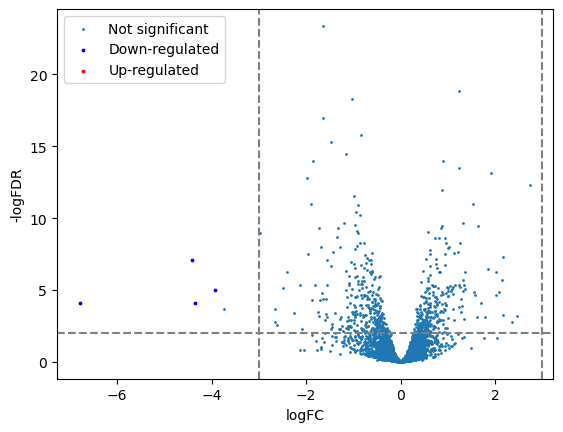

In [29]:
plt.scatter(
    x=full_sorg_results["log2FoldChange"],
    y=full_sorg_results["padj"].apply(lambda x: -np.log10(x)),
    s=1,
    label="Not significant",
)

# highlight down- or up- regulated genes
down_sorg = full_sorg_results[
    (full_sorg_results["log2FoldChange"] <= -3)
    & (full_sorg_results["padj"] <= 0.0001)
]
up_sorg = full_sorg_results[
    (full_sorg_results["log2FoldChange"] >= 3) & (full_sorg_results["padj"] <= 0.0001)
]

plt.scatter(
    x=down_sorg["log2FoldChange"],
    y=down_sorg["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Down-regulated",
    color="blue",
)
plt.scatter(
    x=up_sorg["log2FoldChange"],
    y=up_sorg["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Up-regulated",
    color="red",
)
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3, color="grey", linestyle="--")
plt.axvline(3, color="grey", linestyle="--")
plt.axhline(2, color="grey", linestyle="--")
plt.legend()

In [30]:
up_sorg

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj


In [31]:
plt.scatter(
    x=full_results["log2FoldChange"],
    y=full_results["padj"].apply(lambda x: -np.log10(x)),
    s=1,
    label="Not significant",
)

# highlight down- or up- regulated genes
down = full_results[
    (full_results["log2FoldChange"] <= -3) & (full_results["padj"] <= 0.0001)
]
up = full_results[
    (full_results["log2FoldChange"] >= 3) & (full_results["padj"] <= 0.0001)
]

plt.scatter(
    x=down["log2FoldChange"],
    y=down["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Down-regulated",
    color="blue",
)
plt.scatter(
    x=up["log2FoldChange"],
    y=up["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Up-regulated",
    color="red",
)
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3, color="grey", linestyle="--")
plt.axvline(3, color="grey", linestyle="--")
plt.axhline(2, color="grey", linestyle="--")
plt.legend()

NameError: name 'full_results' is not defined

In [ ]:
up